In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# n_estimators=100 means we are creating a committee of 100 junior scouts to vote on the outcome
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [6]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred = rf_model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 68.07%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.68      0.67      1920
           1       0.70      0.69      0.69      2126

    accuracy                           0.68      4046
   macro avg       0.68      0.68      0.68      4046
weighted avg       0.68      0.68      0.68      4046



<Axes: >

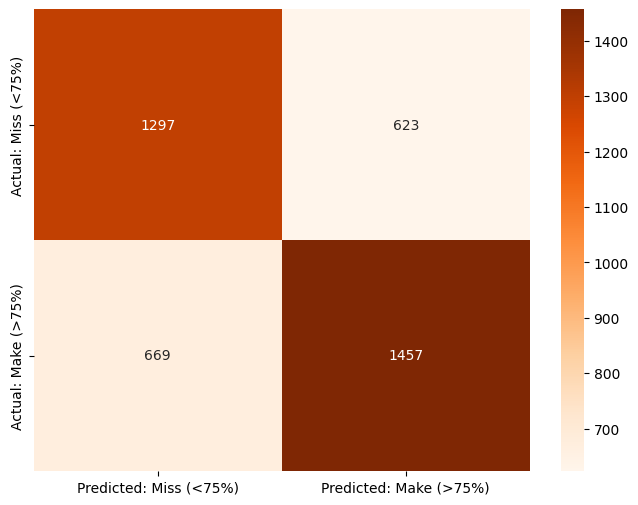

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted: Miss (<75%)', 'Predicted: Make (>75%)'], 
            yticklabels=['Actual: Miss (<75%)', 'Actual: Make (>75%)'])

In [10]:
plt.savefig('rf_confusion_matrix.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>